In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.join(os.path.abspath(""), "../src/python"))

from config import (
    LANGUAGES,
    RESULT_DIR,
    repositories_lang_sample_pickle_path,
)
from git_operate import get_repo

plt.rcParams["font.size"] = 14

In [ ]:
def get_language_intro_datetime(language: str):
    if language == "java":
        return pd.Timestamp("2014-03-17T00:00:00Z", tz="UTC")
    elif language == "javascript":
        return pd.Timestamp("2015-06-01T00:00:00Z", tz="UTC")
    elif language == "cpp":
        return pd.Timestamp("2010-08-12T00:00:00Z", tz="UTC")
    elif language == "csharp":
        return pd.Timestamp("2007-11-18T00:00:00Z", tz="UTC")
    elif language == "php":
        return pd.Timestamp("2019-11-27T00:00:00Z", tz="UTC")
    elif language == "ruby":
        return pd.Timestamp("2009-01-29T00:00:00Z", tz="UTC")
    else:
        raise ValueError("Invalid language")


def get_language_replacement_df(language: str) -> pd.DataFrame:
    rq2_csv_path = RESULT_DIR / "rq2" / f"{language}.csv"
    if rq2_csv_path.exists():
        df = pd.read_csv(rq2_csv_path)
        df["committed_date"] = df["committed_date"].apply(pd.to_datetime)
        return df

    base_dir = RESULT_DIR / "lambda_replacement" / language
    project_result_paths = list(base_dir.glob("*/**/*.pkl"))

    res = pd.DataFrame(columns=["project", "commit", "committed_date"])

    for project_result_path in project_result_paths:
        name_with_owner = (
            f"{project_result_path.parent.name}/{project_result_path.stem}"
        )
        df = pd.read_pickle(project_result_path)

        repo = get_repo(name_with_owner, language)

        replace_df = df[(df["status"] == "insert") | (df["status"] == "update")].copy()

        if replace_df.empty:  # 空のDataFrameをスキップ
            continue

        replace_df["project"] = name_with_owner

        replace_df_commit = replace_df["commit"].unique()

        commit_date_d = {
            commit_hexsha: repo.commit(commit_hexsha).committed_datetime
            for commit_hexsha in replace_df_commit
        }

        replace_df["committed_date"] = replace_df["commit"].map(commit_date_d)
        replace_df["relative_date"] = replace_df["committed_date"].apply(
            lambda x: (x - get_language_intro_datetime(language)).days
        )

        res = (
            pd.concat([res, replace_df], ignore_index=True)
            if not res.empty
            else replace_df
        )

    res.to_csv(RESULT_DIR / "rq2" / f"{language}.csv", index=False)

    return res


def get_project_created_data(language: str) -> pd.DataFrame:
    language_df = pd.read_pickle(repositories_lang_sample_pickle_path(language))

    res = []

    base_dir = RESULT_DIR / "lambda_replacement" / language
    project_result_paths = list(base_dir.glob("*/**/*.pkl"))

    for project_result_path in project_result_paths:
        name_with_owner = (
            f"{project_result_path.parent.name}/{project_result_path.stem}"
        )
        df = pd.read_pickle(project_result_path)
        replace_df = df[((df["status"] == "insert") | (df["status"] == "update"))]
        if replace_df.shape[0] == 0:
            continue

        created_date = pd.to_datetime(
            language_df.loc[
                language_df["Name with Owner"] == name_with_owner, "Created Timestamp"
            ].iloc[0]
        )

        relative_date = (created_date - get_language_intro_datetime(language)).days

        res.append((name_with_owner, created_date, relative_date))

    return pd.DataFrame(res, columns=["project", "created_date", "relative_date"])


def language_for_title(language: str):
    if language == "java":
        return "Java"
    elif language == "javascript":
        return "JavaScript"
    elif language == "cpp":
        return "C++"
    elif language == "csharp":
        return "C#"
    elif language == "php":
        return "PHP"
    elif language == "ruby":
        return "Ruby"
    else:
        raise ValueError("Invalid language")

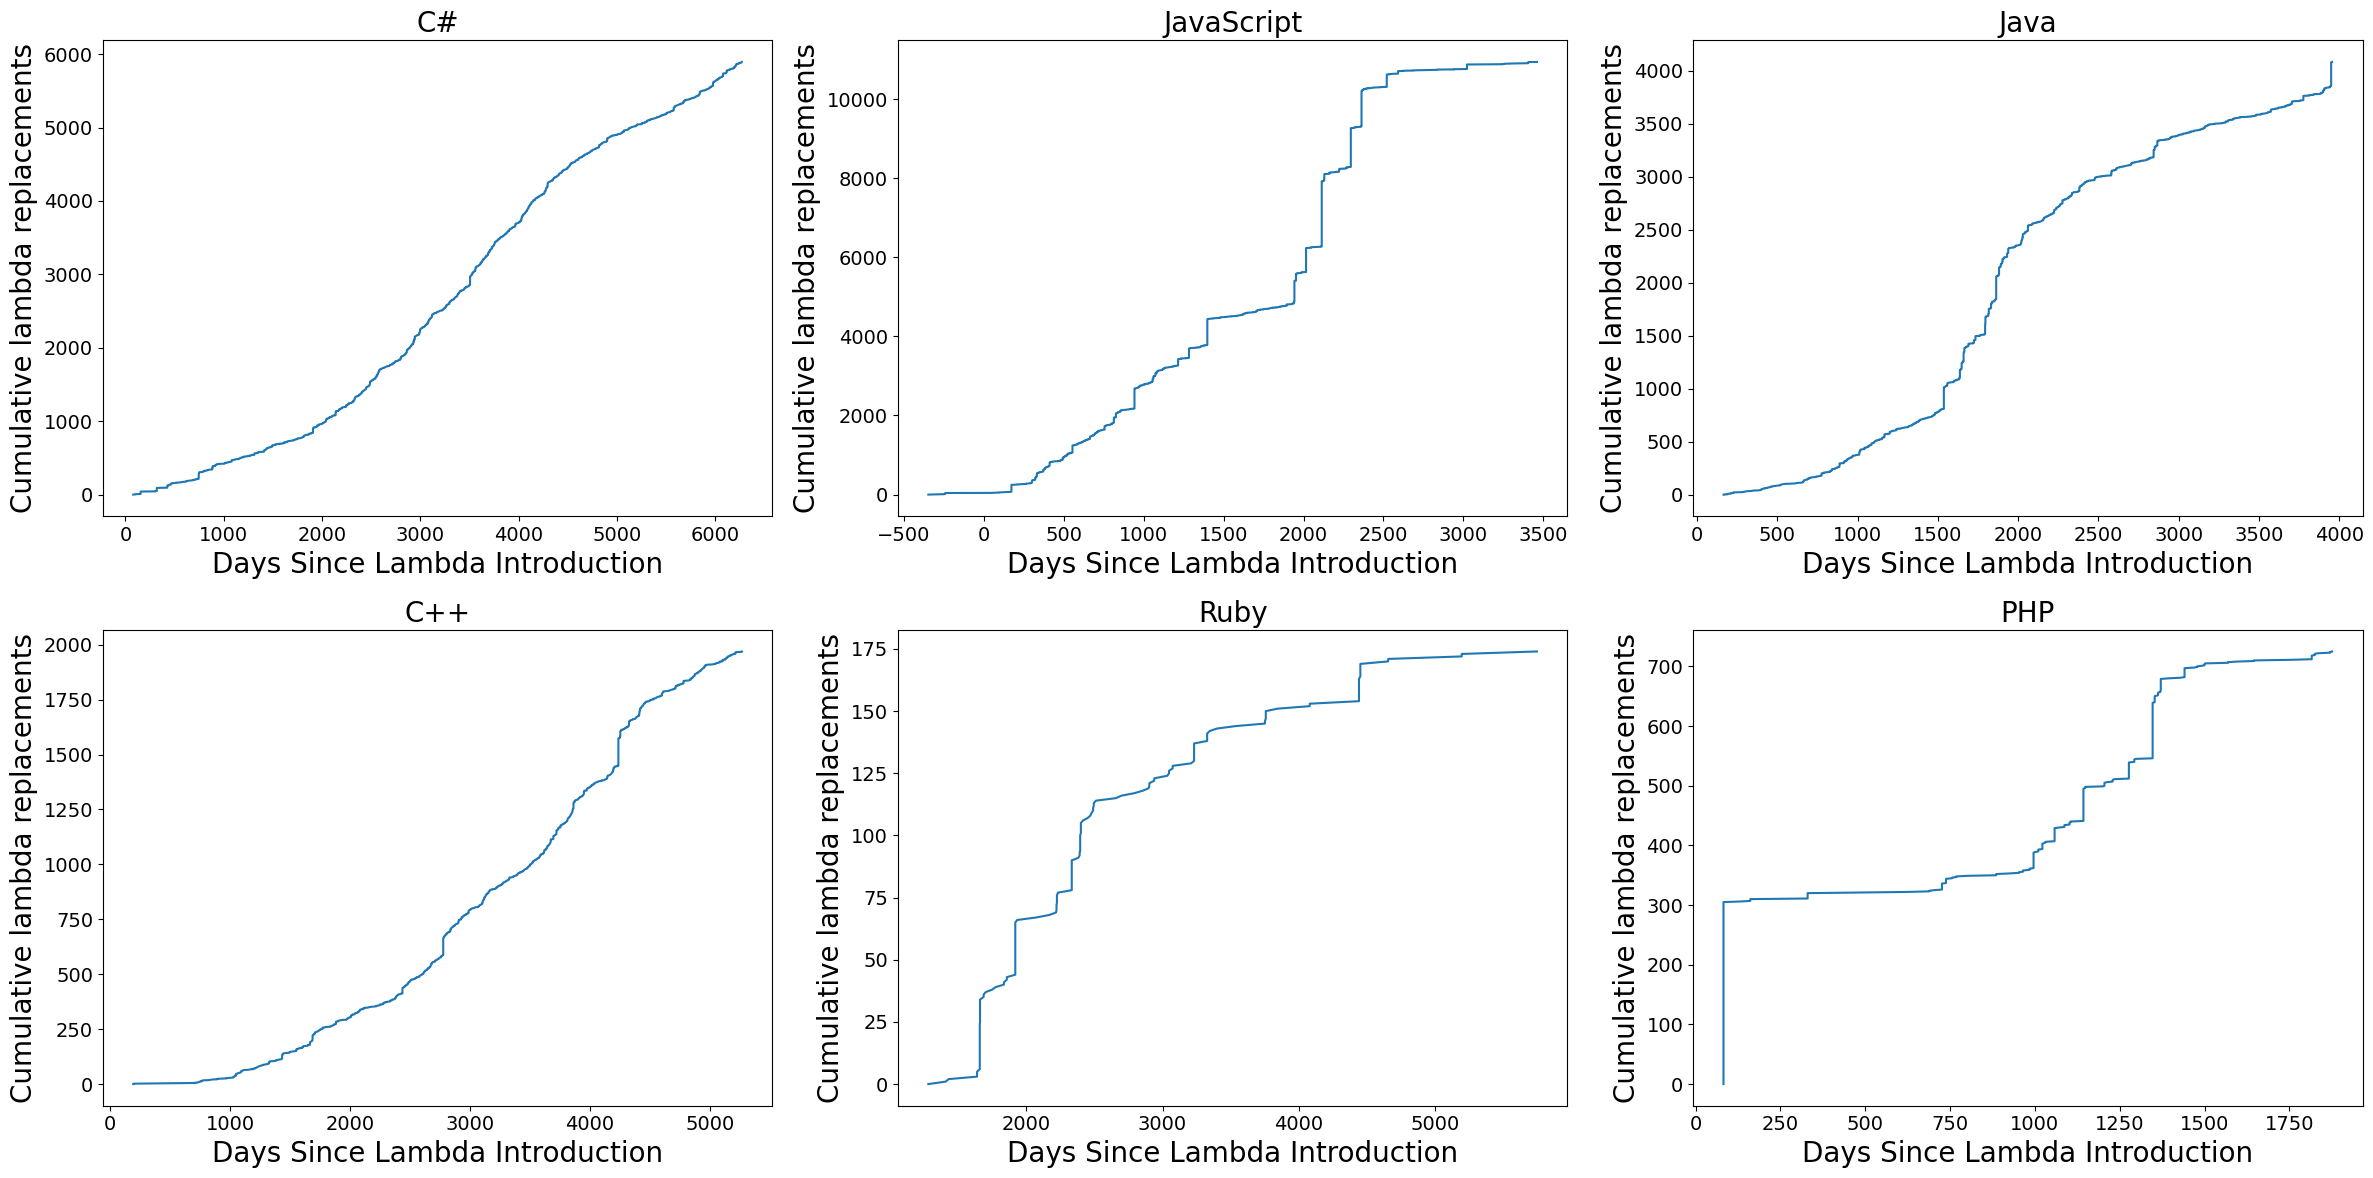

In [31]:
def rq2_replacement_cumulative(ax, language: str, log_scale: bool = False):
    df = get_language_replacement_df(language)

    df["relative_date"] = df["committed_date"].apply(
        lambda x: (x - get_language_intro_datetime(language)).days
    )

    dates = df["relative_date"].tolist()
    dates.sort()

    indices = list(range(len(dates)))

    ax.plot(dates, indices)

    ax.set_xlabel("Days Since Lambda Introduction", fontsize=20)
    ax.set_ylabel("Cumulative lambda replacements", fontsize=20)

    if log_scale:
        ax.set_yscale("log")

    ax.set_title(language_for_title(language), fontsize=20)


fig, axes = plt.subplots(2, 3, figsize=(24, 12))

axes = axes.flatten()

for ax, language in zip(axes, LANGUAGES):
    rq2_replacement_cumulative(ax, language)

plt.tight_layout()

plt.savefig(RESULT_DIR / "rq2" / "rq2_replacement_cumulative_all_languages.pdf")

plt.show()
plt.close()

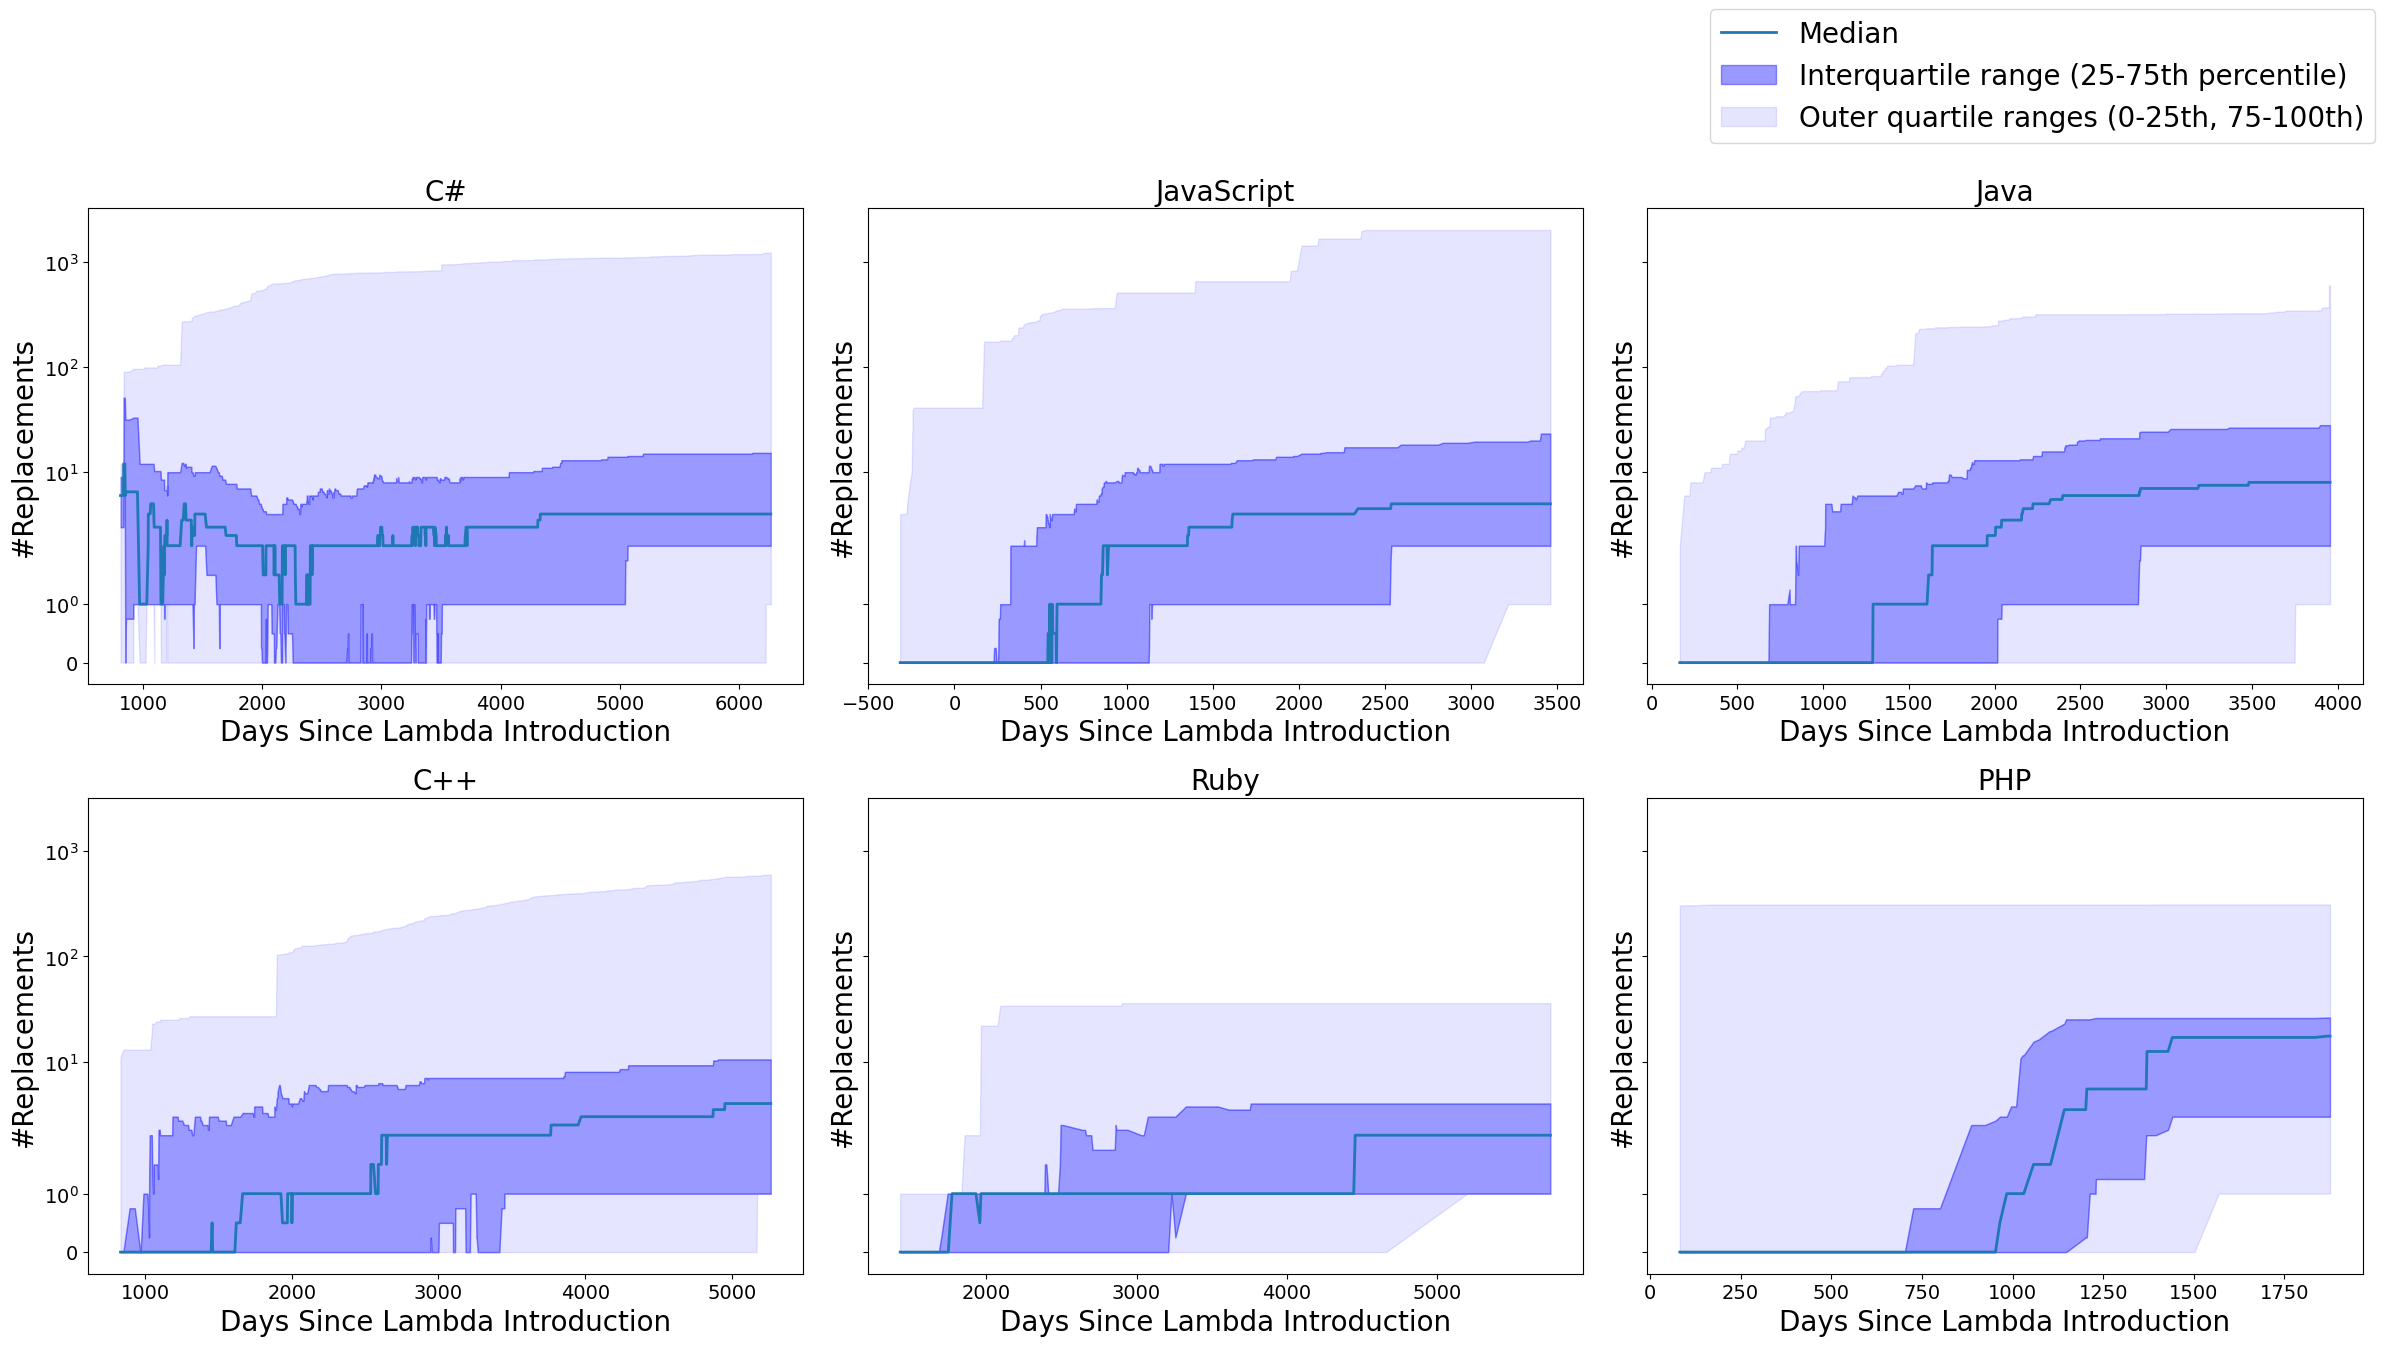

In [ ]:
def create_subfigure(ax, language: str):
    df = get_language_replacement_df(language)

    df["relative_date"] = df["committed_date"].apply(
        lambda x: (x - get_language_intro_datetime(language)).days
    )

    created_df = get_project_created_data(language)
    replacement_times = df["relative_date"]
    creation_times = created_df["relative_date"]

    timeline = sorted(set(replacement_times) | set(creation_times))
    timeline = pd.Index(timeline)

    daily = df.groupby(["project", "relative_date"]).size().rename("cnt").reset_index()

    counts = daily.pivot_table(
        index="relative_date", columns="project", values="cnt", fill_value=0
    )

    counts = counts.reindex(timeline, fill_value=0)

    cum = counts.cumsum()

    project_created_df = get_project_created_data(language)

    created_dict = dict(
        zip(project_created_df.project, project_created_df.relative_date)
    )

    for p, created in created_dict.items():
        if p in cum.columns:
            cum.loc[cum.index < created, p] = None

    percentiles = cum.quantile([0.0, 0.25, 0.5, 0.75, 1.0], axis=1).T
    percentiles.columns = ["p0", "p25", "p50", "p75", "p100"]

    percentiles = percentiles[percentiles["p100"] > 0]

    x = percentiles.index

    (line,) = ax.plot(x, percentiles["p50"], linewidth=2)

    outer1 = ax.fill_between(
        x,
        percentiles["p0"],
        percentiles["p25"],
        color="blue",
        alpha=0.1,
    )

    iqr = ax.fill_between(
        x,
        percentiles["p25"],
        percentiles["p75"],
        color="blue",
        alpha=0.4,
    )

    outer2 = ax.fill_between(
        x,
        percentiles["p75"],
        percentiles["p100"],
        color="blue",
        alpha=0.1,
    )

    ax.set_xlabel("Days Since Lambda Introduction", fontsize=20)
    ax.set_ylabel("#Replacements", fontsize=20)
    ax.set_title(language_for_title(language), fontsize=20)
    ax.set_yscale("symlog")

    return line, iqr, outer1


fig, axes = plt.subplots(2, 3, figsize=(24, 12), sharey=True)

axes = axes.flatten()  # 2次元 → 1次元

handles = None

LANGUAGES = ["csharp", "javascript", "java", "cpp", "ruby", "php"]

for ax, language in zip(axes, LANGUAGES):
    line, iqr, outer = create_subfigure(ax, language)

    # if handles is None:
    #     handles = [line, iqr, outer]
    handles = [line, iqr, outer]

labels = [
    "Median",
    "Interquartile range (25-75th percentile)",
    "Outer quartile ranges (0-25th, 75-100th)",
]

fig.legend(
    handles,
    labels,
    loc="lower right",
    bbox_to_anchor=(1, 1),  # 凡例をグラフの右外側中央に配置
    fontsize=20,
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR / "rq2" / "rq2_replacement_distribution_all_languages.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

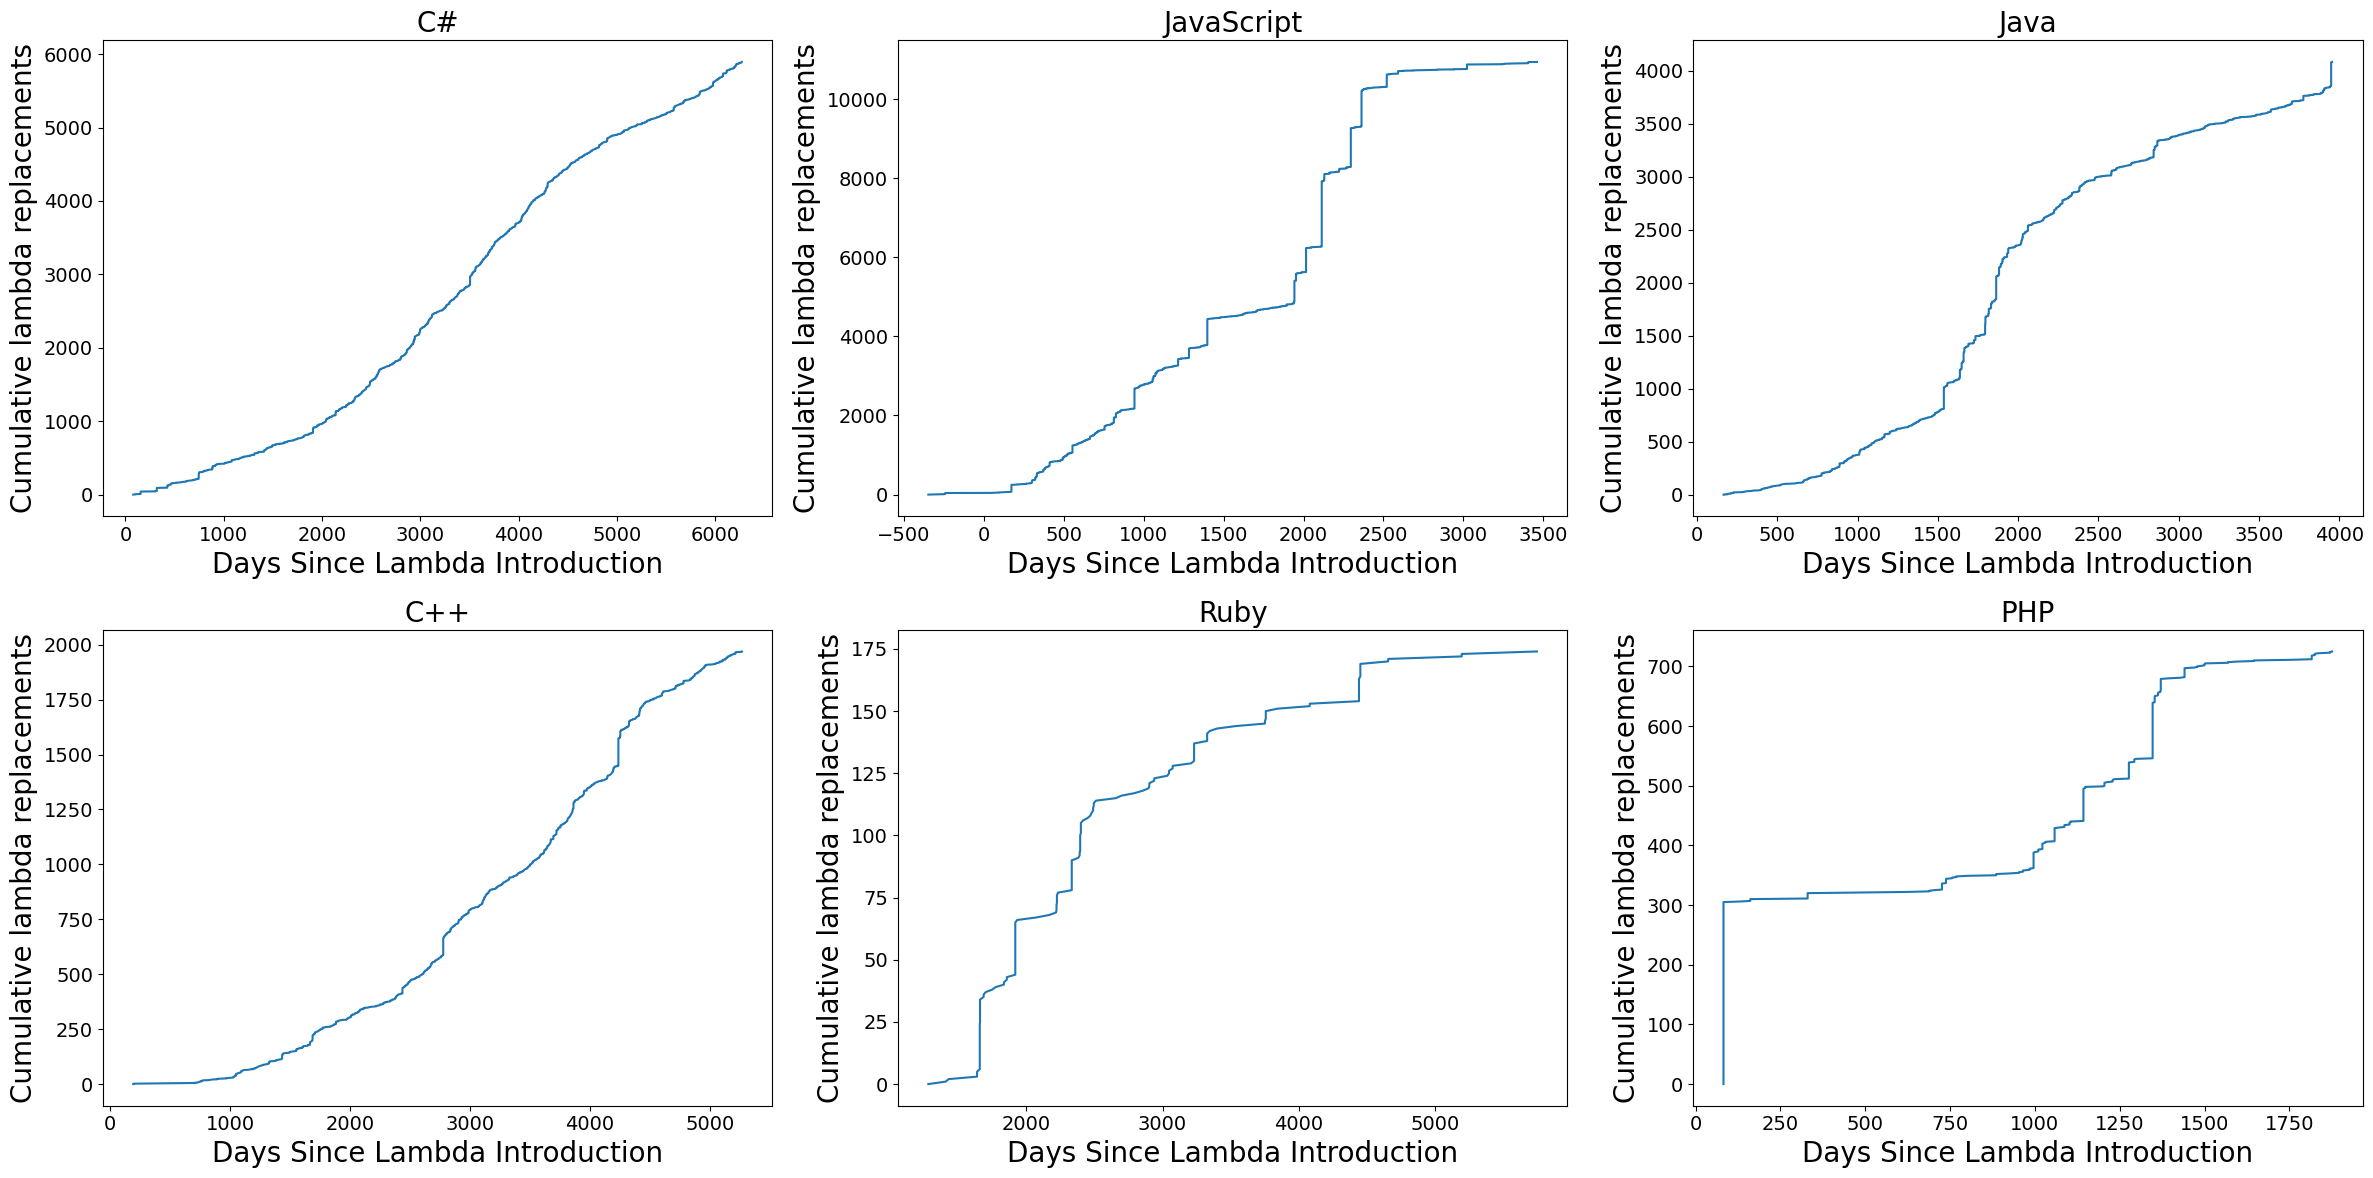